In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("/Users/utkarshyadav/workspace/ai&ds/invoice freight machine learning/data/inventory.db")
table = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(table['name'].values)

['purchases' 'purchase_prices' 'vendor_invoice' 'begin_inventory'
 'end_inventory']


In [3]:
for tab in table["name"]:
    print('table name', tab)
    df = pd.read_sql_query(f'select * from {tab} limit 5' , conn)
    display(df)

table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [8]:
purchase_agg_df = pd.read_sql_query(""" 
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item__quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay

from purchases p
group by p.PONumber
""", conn)

In [19]:
df = pd.read_sql_query(""" 
WITH purchase_agg AS ( 
    select 
        p.PONumber,
        count(distinct p.Brand) as total_brands,
        sum(p.Quantity) as total_item_quantity,
        sum(p.Dollars) as total_item_dollars,  -- already present
        avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
    from purchases p
    group by p.PONumber
)

select 
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.Invoicedate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.payDate) - julianday(vi.Invoicedate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,  
    pa.avg_receiving_delay

from vendor_invoice vi
LEFT JOIN purchase_agg pa 
    ON vi.PONumber = pa.PONumber
""", conn)

In [20]:
df.describe()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,6058.880931,5.807338e+04,295.954301,16.424499,35.468519,41.312466,6058.880931,5.807338e+04,7.671541
std,14453.338164,1.402340e+05,713.585093,3.127282,5.842178,76.940674,14453.338164,1.402340e+05,1.824496
min,1.000000,4.140000e+00,0.020000,9.000000,23.000000,1.000000,1.000000,4.140000e+00,3.000000
25%,83.000000,9.678100e+02,5.020000,14.000000,31.000000,3.000000,83.000000,9.678100e+02,6.129178
50%,423.000000,4.765450e+03,24.730000,16.000000,35.000000,7.000000,423.000000,4.765450e+03,7.744898
75%,5100.500000,4.458718e+04,229.660000,19.000000,40.000000,46.000000,5100.500000,4.458718e+04,9.083804
max,141660.000000,1.660436e+06,8468.220000,23.000000,48.000000,807.000000,141660.000000,1.660436e+06,13.000000


In [21]:
def create_invoice_risk_label(row):
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5 ):
        return 1 
        
    if row["avg_receiving_delay"] > 10:
        return 1 

    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

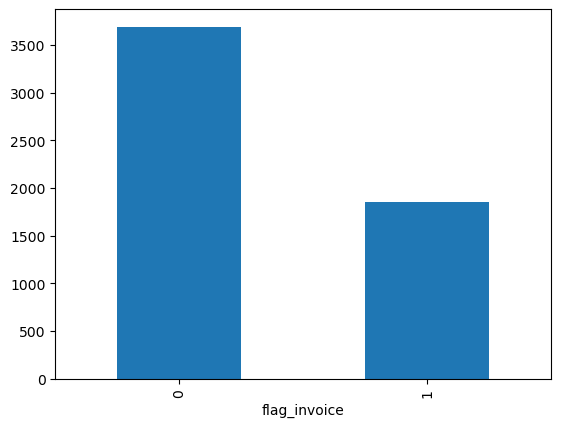

In [23]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

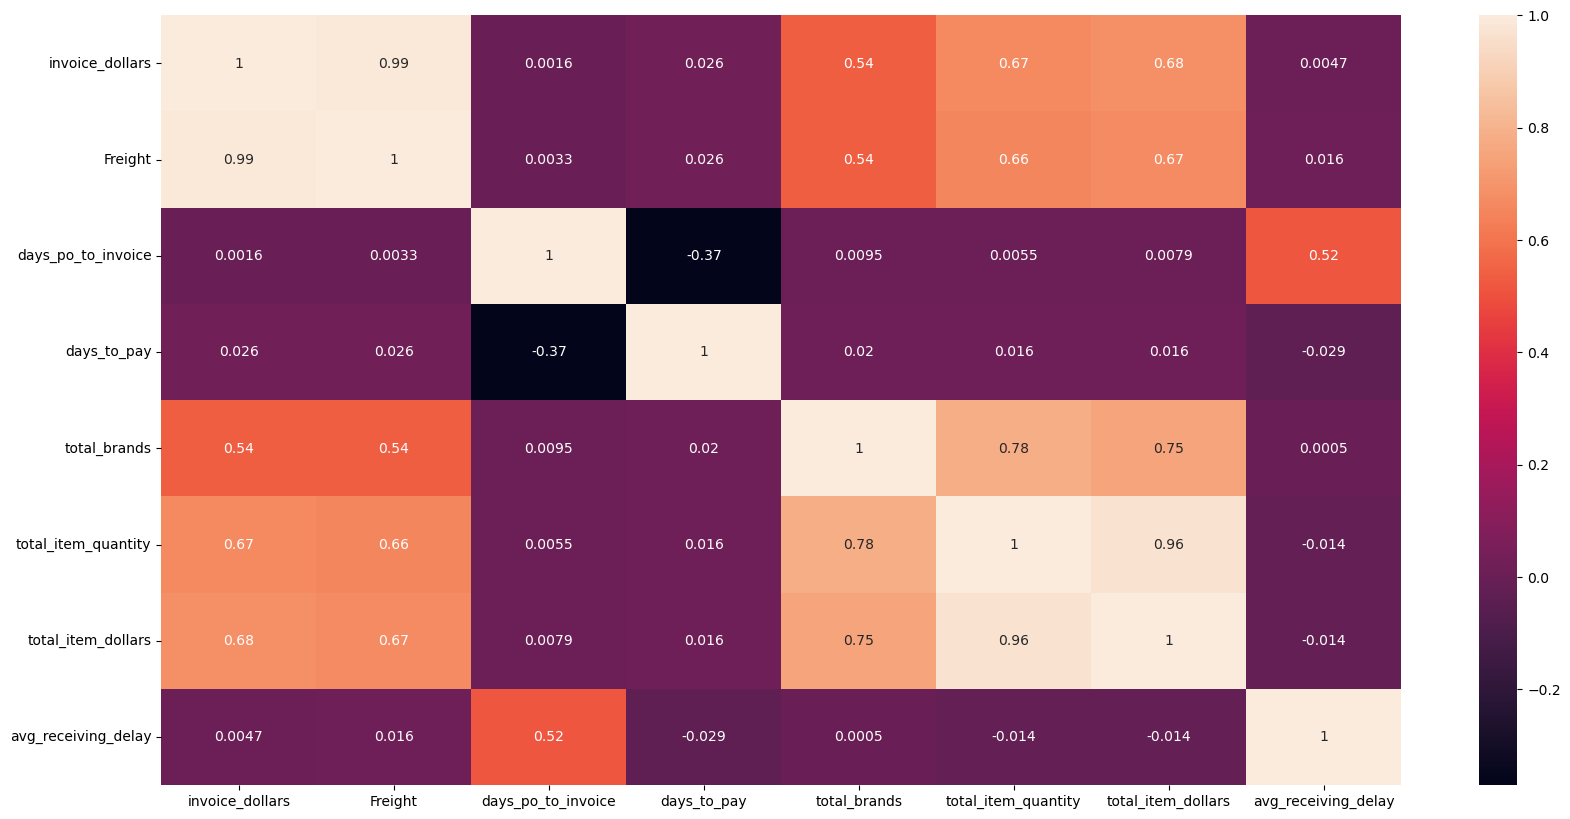

In [31]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot = True)
plt.show()

In [32]:
flagged = df[df["flag_invoice"] == 1 ]
normal = df[df["flag_invoice"] == 0 ]

In [38]:
significant_feature = []
non_significant_feature = []
result = []

In [34]:
metrics = ['invoice_quantity' , 'invoice_dollars' , 'Freight' , 
           'days_po_to_invoice' , 'days_to_pay' , 'total_brands' ,
           'total_item_quantity' , 'total_item_dollars' , 'avg_receiving_delay']
           

In [39]:
from scipy.stats import ttest_ind 
for metric in metrics :
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_feature.append(metric)
        result.append({
            "metric":metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(3),
            "p_value":p_value.round(3)
        })
    else:
        non_significant_feature.append(metric)

In [41]:
significant_feature

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [49]:
from sklearn.model_selection import train_test_split
x = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'days_po_to_invoice' , 'total_item_dollars']]
y = df['flag_invoice']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [50]:
x.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,141660.0,23.0,1660436.0


In [51]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, preds)*100

    print(f'\n{model_name} Performance:')
    print(f'MAE : {mae: .2f}')
    print(f'RMSE : {rmse: .2f}')
    print(f'R2 : {r2: .2f}%')

In [63]:
model1 = LogisticRegression(random_state=42)
model1.fit(x_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(x_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [64]:
evaluate_model(model1, x_test_scaled, y_test, 'Logistic Regression ' )
evaluate_model(model2, x_test_scaled, y_test, 'Decision Tree Classifier ' )
evaluate_model(model3, x_test_scaled, y_test, 'Random Forest Classifier ' )


Logistic Regression  Performance:
MAE :  0.34
RMSE :  0.58
R2 : -50.18%

Decision Tree Classifier  Performance:
MAE :  0.20
RMSE :  0.44
R2 :  13.16%

Random Forest Classifier  Performance:
MAE :  0.12
RMSE :  0.35
R2 :  46.22%


In [65]:
feature_importance = pd.DataFrame({
    "feature" : x_train.columns,
    "importance" : model3.feature_importances_
}).sort_values(by="importance" , ascending=False)

feature_importance

,feature,importance
5,total_item_dollars,0.262827
3,total_item_quantity,0.210298
1,invoice_dollars,0.157548
0,invoice_quantity,0.149574
2,Freight,0.143837
4,days_po_to_invoice,0.075916


In [69]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf  = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 4, 5, 6],
    "min_samples_split" : [2, 3, 5],
    "min_samples_leaf" : [1, 2 , 5 ],
    "criterion" : ['gini', 'entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid= param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train)
evaluate_model(grid_search, x_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.3s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   5.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.7s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.7s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.6s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; total time=   3.3s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=300; total time=   4.7s
[CV] END criterion=gini, max_depth=None, min_sam

In [71]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid_search.predict(x_test_scaled), y_test)

array([[709, 121],
       [ 16, 263]])

In [72]:
confusion_matrix(model3.predict(x_test_scaled), y_test)

array([[707, 117],
       [ 18, 267]])

In [73]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}